# Introduction
This analysis extends Assignment 1 by applying advanced machine learning techniques to deepen the understanding of how the ASC can build fan support for Brisbane 2032. Three analytical cycles are conducted:

- Cycle 1 (Structured — K-Means Clustering): Extends Assignment 1's manual participation trend categorisation to all 27 confirmed Olympic sports using K-Means clustering
- Cycle 2 (Structured — Barriers Analysis): Investigates what barriers prevent children aged 5-17 from participating in sports using AusPlay national data
- Cycle 3 (Semi-structured — LDA Topic Modelling): Analyses Guardian Australia articles to understand the concerns that led to the social media ban and how ASC can use these insights for a targeted marketing campaign

Together these three cycles provide the ASC with a comprehensive data-driven strategy for building fan support ahead of Brisbane 2032.

# Question

**Concern:** Based on the analysis in assignment 1 the ASC wants to create fan support for Olympic 2032. The analysis showed that not every sport goes through same participation trend and categorized them manually in four groups (Mixed/unclear trend (U shaped), Increasing with age, Decreasing with age, relatively stable). However, the scope of the analysis was limited to only top ten most participated Olympic sports based on the Ausplay dataset and in this analysis the scope will be expanded to all 27 sports covering all confirmed Olympic sports, to find and confirm participation trend using Machine learning (K-Means) because, unlike the manual categorization in Assignment 1, K-Means provides an objective, data-driven approach to grouping sports reducing potential bias in the analysis. The Brisbane 2032 Olympics is within 6 years, and ASC should provide support for all sports and create fan support for them and by understanding participation trend it will be able to have more specific pln for each trend.

> **Question:** Can K-Means clustering confirm the participation trend categories identified in Assignment 1 based on age group trends and expand it for all 27 confirmed Brisbane 2032 Olympic sports so ASC can have a broader strategic plan for creating fan support for every sport?

### Key Stakeholders

- **ASC** will make better decision based on the findings.
- **Government** will benefit politically from successful Brisbane 2032 and can provide funds for public sports infrastructure. Moreover, it is interested in children health.
- **Sport clubs** will receive more funding if ASC invests in their sport and will have more members as investment and promotion increases.
- **Professional Athletes playing in every confirmed Olympic sport** will gain more fans and more funding.

### Why this Question is significant

With manual clustering the analysis was limited to only human perception which can lead to biases and categorizing 27 sports manually wasn't easy so by using a more strategic data driven tool the clustering would be more precise. The ASC is responsible for all sports held on Brisbane 2032 and the Olympics are not just about 10 top most participated sport in Australia. With this data ASC can have a more tailored strategy for individual groups and eventually have better outcome which is creating fan support for sports. With Brisbane 2032 only 6 years away, having a data-driven strategy for all 27 sports now gives ASC enough time to implement targeted fan engagement plans.

# Data

The analysis use the  df_olympic data frame used in assignment 1, only the age group columns (5-8, 9-11, 12-14, 15-17) are used as features because they represent the participation trend across age groups which is what we want to cluster on. The total, males and females columns are excluded as they don't contribute to trend shape. for values we need to normalize the values using the [normalize()]( https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html) method as the participation numbers vary across different sports and skews the data which leads to biased analysis. Row-wise normalisation is used so that each sport's participation is scaled relative to itself, allowing the trend shape to be compared across sports regardless of their overall participation size.

In [2]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

In [3]:
# Loading the df_Olympic csv file 
file_path = "data/"
file_name = "df_olympic.csv"
df_olympic = pd.read_csv(f"{file_path}{file_name}")
df_olympic

,Sports Name,total,5-8,9-11,12-14,15-17
0,"Athletics, track and field",2.053957e+05,53332.220154,45772.153889,37553.679697,49060.452473
1,Badminton,1.100375e+05,7797.761540,7244.605036,14028.111061,73825.687440
2,Basketball,5.024981e+05,97252.948855,105177.424498,124325.819536,160131.829928
3,Boxing,3.105555e+04,3847.392572,5355.226062,7166.201064,13532.802886
4,Canoeing/Kayaking,1.855113e+04,743.323304,1899.941670,1949.046671,12637.185008
5,Cycling,1.422156e+05,29391.657772,18700.215850,15343.821911,59186.917667
6,Diving,3.721311e+03,662.703109,1178.515645,1113.936981,0.000000
7,Equestrian,1.782911e+04,2971.942781,5792.408187,2419.023003,3606.626338
8,Fencing,8.220364e+03,0.000000,520.994140,1944.387221,3644.160673
9,Football/soccer,8.822976e+05,239439.897817,217361.968928,161372.963119,181202.174438


In [4]:
# selecting columns(features) used for the analysis
features = df_olympic[['5-8','9-11','12-14','15-17']]
features

,5-8,9-11,12-14,15-17
0,53332.220154,45772.153889,37553.679697,49060.452473
1,7797.761540,7244.605036,14028.111061,73825.687440
2,97252.948855,105177.424498,124325.819536,160131.829928
3,3847.392572,5355.226062,7166.201064,13532.802886
4,743.323304,1899.941670,1949.046671,12637.185008
5,29391.657772,18700.215850,15343.821911,59186.917667
6,662.703109,1178.515645,1113.936981,0.000000
7,2971.942781,5792.408187,2419.023003,3606.626338
8,0.000000,520.994140,1944.387221,3644.160673
9,239439.897817,217361.968928,161372.963119,181202.174438


In [5]:
# norm= l1'  means that it sum each rows columns and then divide each by the total. the sum of norm value of all columns will be 1 in this way — scales each sport's participation relative to itself.
features_row_normalized = normalize(features, norm='l1')
features_row_normalized

array([[0.28716697, 0.24645984, 0.20220753, 0.26416566],
       [0.07578282, 0.07040695, 0.13633269, 0.71747754],
       [0.19974397, 0.21601974, 0.25534787, 0.32888841],
       [0.12866835, 0.17909483, 0.23965927, 0.45257754],
       [0.04314249, 0.11027262, 0.11312267, 0.73346223],
       [0.23969199, 0.15250218, 0.12513044, 0.48267539],
       [0.22425319, 0.39879984, 0.37694696, 0.        ],
       [0.20094271, 0.39164355, 0.16355801, 0.24385573],
       [0.        , 0.08527548, 0.31825417, 0.59647035],
       [0.29953313, 0.27191421, 0.20187341, 0.22667924],
       [0.53798374, 0.27294214, 0.10504887, 0.08402525],
       [0.06362518, 0.14441506, 0.12463021, 0.66732955],
       [0.45427003, 0.04744175, 0.2569158 , 0.24137241],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.43505618, 0.56494382],
       [0.06111752, 0.42027101, 0.14357801, 0.37503346],
       [0.43103685, 0.26974397, 0.11016375, 0.18905543],
       [0.489014  , 0.19243774,

In [6]:
features_norm_df = pd.DataFrame(
    features_row_normalized, 
    columns=['5-8_norm', '9-11_norm', '12-14_norm', '15-17_norm']
)

# Add normalised columns to df_olympic
df_olympic = pd.concat([df_olympic, features_norm_df], axis=1)
df_olympic

,Sports Name,total,5-8,9-11,12-14,15-17,5-8_norm,9-11_norm,12-14_norm,15-17_norm
0,"Athletics, track and field",2.053957e+05,53332.220154,45772.153889,37553.679697,49060.452473,0.287167,0.246460,0.202208,0.264166
1,Badminton,1.100375e+05,7797.761540,7244.605036,14028.111061,73825.687440,0.075783,0.070407,0.136333,0.717478
2,Basketball,5.024981e+05,97252.948855,105177.424498,124325.819536,160131.829928,0.199744,0.216020,0.255348,0.328888
3,Boxing,3.105555e+04,3847.392572,5355.226062,7166.201064,13532.802886,0.128668,0.179095,0.239659,0.452578
4,Canoeing/Kayaking,1.855113e+04,743.323304,1899.941670,1949.046671,12637.185008,0.043142,0.110273,0.113123,0.733462
5,Cycling,1.422156e+05,29391.657772,18700.215850,15343.821911,59186.917667,0.239692,0.152502,0.125130,0.482675
6,Diving,3.721311e+03,662.703109,1178.515645,1113.936981,0.000000,0.224253,0.398800,0.376947,0.000000
7,Equestrian,1.782911e+04,2971.942781,5792.408187,2419.023003,3606.626338,0.200943,0.391644,0.163558,0.243856
8,Fencing,8.220364e+03,0.000000,520.994140,1944.387221,3644.160673,0.000000,0.085275,0.318254,0.596470
9,Football/soccer,8.822976e+05,239439.897817,217361.968928,161372.963119,181202.174438,0.299533,0.271914,0.201873,0.226679


Modern pentathlon and Triathlon both are marked as ** which means margin of error greater then 100% and they stand out:

Modern pentathlon: has 0 participants across all age groups which leads a zero value after normalization due to this, the sport will be removed from the clustering it will be discussed in the insight and ethical considerations.

Triathlon: it has only 709 estimated participants concentrated entirely in the 12-14 age group with zero in all other groups. This unique pattern would force K-Means to create a separate cluster just for Triathlon which is not analytically meaningful. Therefore, Triathlon will also be removed from clustering but discussed in insights and ethical considerations.



In [7]:
removed_sports = ['Modern pentathlon','Triathlon']

df_olympic_cluster = df_olympic[~df_olympic['Sports Name'].isin(removed_sports)]

print(f"number of clustring sports: {len(df_olympic_cluster)}")

number of clustring sports: 25


# Analysis 

Now that we have the normalised values it's time to feed them to the K-Means algorithm.

In [8]:
features_cluster = df_olympic_cluster[['5-8', '9-11', '12-14', '15-17']]

# normalize it 
features_normalized = normalize(features_cluster, norm='l1')

for k in [3, 4, 5]:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(features_normalized)
    df_olympic_cluster[f'cluster_k{k}'] = kmeans_test.labels_
    print(f"\nk={k}:")
    print(df_olympic_cluster[['Sports Name', f'cluster_k{k}', '5-8_norm', '9-11_norm', '12-14_norm', '15-17_norm']].sort_values(f'cluster_k{k}').to_string())


k=3:
                        Sports Name  cluster_k3  5-8_norm  9-11_norm  12-14_norm  15-17_norm
0        Athletics, track and field           0  0.287167   0.246460    0.202208    0.264166
7                        Equestrian           0  0.200943   0.391644    0.163558    0.243856
6                            Diving           0  0.224253   0.398800    0.376947    0.000000
9                   Football/soccer           0  0.299533   0.271914    0.201873    0.226679
12                             Judo           0  0.454270   0.047442    0.256916    0.241372
16                         Swimming           0  0.431037   0.269744    0.110164    0.189055
10                       Gymnastics           0  0.537984   0.272942    0.105049    0.084025
17            Synchronised swimming           0  0.489014   0.192438    0.318548    0.000000
19             Taekwondo/Taekwon-do           0  0.350125   0.304396    0.182915    0.162564
23                       Water polo           0  0.116000   0.37

To find the most suitable k value I used a loop with values 3, 4 and 5. 
- K=3 misses the decreasing participation pattern.
- K=5 splits the stable cluster into two where there is no strategic difference, just adding complexity.
- K=4 is the best value as it captures 3 main patterns — stable/mixed, increasing and decreasing — and additionally splits the increasing pattern into strongly (Cluster 1) and moderately (Cluster 2) increasing, providing more strategic value.

***Therefore k=4 was chosen***.

In [9]:
# Apply K-Means with k=4
kmeans = KMeans(n_clusters= 4, random_state=42)
kmeans.fit(features_normalized)

# Add cluster labels back to df_olympic_cluster
df_olympic_cluster['cluster'] = kmeans.labels_


In [10]:
# Showing which sports are in which cluster
df_olympic_cluster[['Sports Name', 'cluster','5-8_norm', '9-11_norm', '12-14_norm', '15-17_norm']].sort_values('cluster')

,Sports Name,cluster,5-8_norm,9-11_norm,12-14_norm,15-17_norm
0,"Athletics, track and field",0,0.287167,0.246460,0.202208,0.264166
2,Basketball,0,0.199744,0.216020,0.255348,0.328888
6,Diving,0,0.224253,0.398800,0.376947,0.000000
7,Equestrian,0,0.200943,0.391644,0.163558,0.243856
15,Sailing,0,0.061118,0.420271,0.143578,0.375033
9,Football/soccer,0,0.299533,0.271914,0.201873,0.226679
19,Taekwondo/Taekwon-do,0,0.350125,0.304396,0.182915,0.162564
20,Tennis,0,0.218122,0.229193,0.221371,0.331313
23,Water polo,0,0.116000,0.371778,0.309774,0.202448
11,Handball,1,0.063625,0.144415,0.124630,0.667330


# Visualisation

For visualization this analysis uses line chart, demonstrating each cluster overall pattern. This plot was chosen because each point represents an age group and lines connecting them demonstrate how participation changes sequentially as age group changes  with X axis being age groups and Y axis being average normalised value of each age group for different clusters. In this way instead of plotting each individual sport which would become crowded the stackholders will be able to make decisions based on the clusters overall pattern.

In [11]:
# calculating each age group avg grouped by cluster

cluster_avg = df_olympic_cluster.groupby('cluster')[['5-8_norm', '9-11_norm', '12-14_norm', '15-17_norm']].mean().reset_index() # without reset indext the cluster would becom index
cluster_avg

,cluster,5-8_norm,9-11_norm,12-14_norm,15-17_norm
0,0,0.217445,0.316719,0.228619,0.237216
1,1,0.036029,0.079735,0.126433,0.757803
2,2,0.073672,0.117383,0.288693,0.520252
3,3,0.478076,0.195641,0.197669,0.128613


In [12]:
# melt the dataframe converting it into a long table to be able to plot it and color it based on the cluster 

cluster_avg_melted = cluster_avg.melt(
    id_vars= 'cluster',
    value_vars= ['5-8_norm', '9-11_norm', '12-14_norm', '15-17_norm'],
    var_name= 'Age group',
    value_name= 'AVG normalised Participation'
)
cluster_avg_melted

,cluster,Age group,AVG normalised Participation
0,0,5-8_norm,0.217445
1,1,5-8_norm,0.036029
2,2,5-8_norm,0.073672
3,3,5-8_norm,0.478076
4,0,9-11_norm,0.316719
5,1,9-11_norm,0.079735
6,2,9-11_norm,0.117383
7,3,9-11_norm,0.195641
8,0,12-14_norm,0.228619
9,1,12-14_norm,0.126433


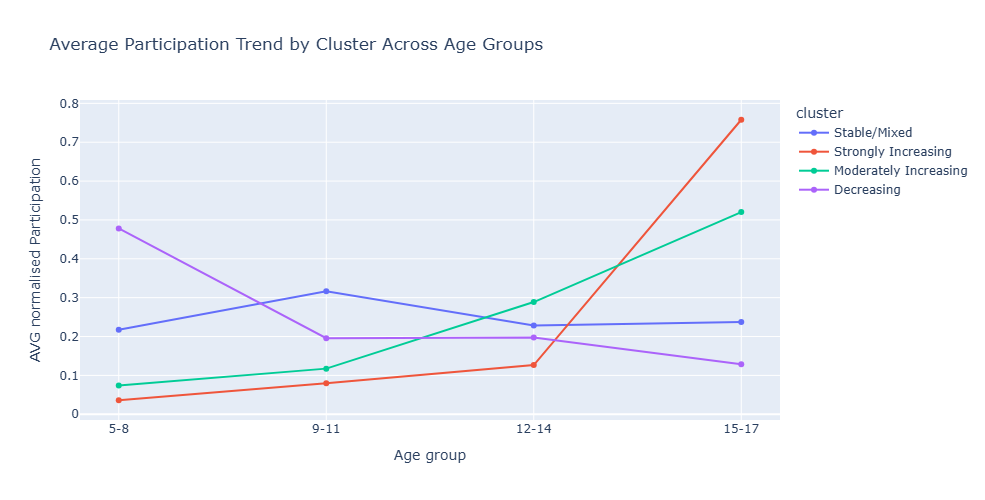

In [13]:
# removing _norm from the age groups names 
cluster_avg_melted['Age group'] = cluster_avg_melted['Age group'].str.replace('_norm', '')
# maping actual cluster names to the cluster Id
cluster_avg_melted['cluster'] = cluster_avg_melted['cluster'].map({
    0: 'Stable/Mixed',
    1: 'Strongly Increasing',
    2: 'Moderately Increasing',
    3: 'Decreasing'
})
# plottin
fig = px.line(
    cluster_avg_melted,
    x='Age group',
    y='AVG normalised Participation',
    color='cluster',
    title='Average Participation Trend by Cluster Across Age Groups',
    markers=True, # adds dots 
    width=900,
    height=500
)
fig.show()

Based on the visualisation, each dot represents each cluster's average participation proportion for a specific age group, and the connecting line demonstrates the change in proportions as the age group changes. As expected, four clusters were recognised by the K-Means algorithm representing distinct patterns:

- Stable/Mixed cluster (blue line) — sports that have a relatively consistent participation proportion across all age groups. (e.g. Basketball, Football/soccer)
- Strongly Increasing cluster (orange line) — sports where the majority of participation is concentrated in the 15-17 age group with less than 25% combined across all other age groups. (e.g. Weight lifting, Wrestling)
- Moderately Increasing cluster (green line) — sports that show a gradual increase in participation proportion sequentially across age groups. (e.g. Cycling, Boxing)
- Decreasing cluster (purple line) — sports that lose participants as age groups increase. (e.g. Gymnastics, Swimming)

These four clusters will be used to provide ASC with targeted strategic recommendations for fan engagement across all 25 confirmed Brisbane 2032 Olympic sports included in this analysis.

Before proceeding with Insight, the margin of error flags from the AusPlay dataset were checked for all 25 sports across age groups. The following table summarises the reliability of each data point:

| Sport | 5-8 | 9-11 | 12-14 | 15-17 | Cluster |
|---|---|---|---|---|---|
| Athletics, track and field | ✅ | ✅ | ✅ | ✅ | 0 - Stable/Mixed |
| Basketball | ✅ | ✅ | ✅ | ✅ | 0 - Stable/Mixed |
| Football/soccer | ✅ | ✅ | ✅ | ✅ | 0 - Stable/Mixed |
| Tennis | ✅ | ✅ | ✅ | ✅ | 0 - Stable/Mixed |
| Taekwondo/Taekwon-do | ✅ | ✅ | * | * | 0 - Stable/Mixed |
| Equestrian | * | * | * | * | 0 - Stable/Mixed |
| Water polo | ** | * | * | ** | 0 - Stable/Mixed |
| Sailing | ** | * | ** | * | 0 - Stable/Mixed |
| Diving | ** | ** | ** | ** | 0 - Stable/Mixed |
| Volleyball (indoor and outdoor) | * | ✅ | ✅ | ✅ | 1 - Strongly Increasing |
| Badminton | * | * | ✅ | ✅ | 1 - Strongly Increasing |
| Table tennis | * | * | ✅ | ✅ | 1 - Strongly Increasing |
| Handball | ** | * | ** | ✅ | 1 - Strongly Increasing |
| Canoeing/Kayaking | ** | ** | ** | ✅ | 1 - Strongly Increasing |
| Weight lifting | ** | ** | ** | ✅ | 1 - Strongly Increasing |
| Wrestling | ** | ** | ** | ** | 1 - Strongly Increasing |
| Cycling | ✅ | ✅ | ✅ | ✅ | 2 - Moderately Increasing |
| Boxing | * | * | * | ✅ | 2 - Moderately Increasing |
| Rowing | ** | ** | * | * | 2 - Moderately Increasing |
| Fencing | ** | ** | ** | * | 2 - Moderately Increasing |
| Shooting | ** | ** | ** | * | 2 - Moderately Increasing |
| Swimming | ✅ | ✅ | ✅ | ✅ | 3 - Decreasing |
| Gymnastics | ✅ | ✅ | ✅ | ✅ | 3 - Decreasing |
| Judo | * | ** | ** | ** | 3 - Decreasing |
| Synchronised swimming | ** | ** | ** | ** | 3 - Decreasing |

Note: Flags are determined by the following thresholds from the AusPlay margin of error tables (Sheet 8):

- '*' flag (50-100% margin of error): child estimates below 8,879 / adult estimates below 10,616
- '**' flag (>100% margin of error): child estimates below 2,223 / adult estimates below 2,655



# Insight

### Can K-Means clustering confirm the participation trend categories identified in Assignment 1 based on age group trends and expand it for all 27 confirmed Brisbane 2032 Olympic sports so ASC can have a broader strategic plan for creating fan support for every sport?

The K-Means clustering somewhat confirmed the manual clustering from Assignment 1. However, due to the broader scope of analysis there are some differences between the manual top 10 Olympic sports and the systematic 25 Olympic sports clusters. With algorithmic clustering, the three main patterns (steady, increasing, and decreasing) are recognised but the U-shaped category containing Swimming and Football/soccer split, with Football/soccer joining the stable/mixed cluster and Swimming joining the decreasing pattern. Additionally, two separate increasing patterns are now identified — strongly increasing and moderately increasing — which were not distinguished in Assignment 1.


#### Key finidngs:

K-Means clustering identified four distinct participation trend categories across all 25 confirmed Brisbane 2032 Olympic sports:

- **Cluster 0 - Stable/Mixed (9 sports):** Athletics track and field, Basketball, Diving, Equestrian, Sailing, Football/soccer, Taekwondo/Taekwon-do, Tennis, Water polo
- **Cluster 1 - Strongly Increasing (7 sports):** Handball, Volleyball (indoor and outdoor), Weight lifting, Table tennis, Wrestling, Canoeing/Kayaking, Badminton
- **Cluster 2 - Moderately Increasing (5 sports):** Fencing, Cycling, Boxing, Rowing, Shooting
- **Cluster 3 - Decreasing (4 sports):** Swimming, Gymnastics, Judo, Synchronised swimming



Based on the data, most Olympic sports fall within the **increasing** pattern where participation grows as children get older. Within the increasing pattern, 7 sports are in the **strongly increasing** group where teenagers contribute the most to the participation proportion. Additionally, this category has the highest number of flagged observations. This is expected as these sports have very low child participation, suggesting they are teenager-entry sports in Australia where children typically don't begin participation until later years.

**Moderately Increasing** also shows significant flagging with 3 out of 5 sports having unreliable data for younger age groups, particularly Fencing, Rowing and Shooting which have no recorded child participants in the 5-8 age group.

The most reliable data comes from the **stable category** which is unsurprising as participation numbers remain somewhat constant across all age groups. 

For the **decreasing** pattern, participation numbers for Swimming and Gymnastics are reliable, however Judo and Synchronised swimming are flagged with **.



#### Strategic recommendations for ASC

Now that we have grouped sports based on their participation pattern, the ASC can tailor its strategy based on the cluster each sport belongs to:

- Stable/Mixed: consistent investment across all age groups is advised
- Strongly Increasing: target the 15-17 age group for fan connection in these sports
- Moderately Increasing: target older age groups (12-14 and 15-17) for fan connection in these sports
- Decreasing: target younger age groups (5-8) urgently before participation drops off

The two sports removed from the analysis require mastery of multiple disciplines.


[Modern Pentathlon](https://www.olympics.com.au/sports/modern-pentathlon/): Fencing, Swimming, Equestrian, Shooting, Running

[Triathlon](https://www.triathlon.org/about/discover/triathlon): Swimming, Cycling, Running 

The complexity of these two sports explains why they have low child participation as children mostly specialise in one sport at a time. However, for creating a fan base strategy for these two sports, the ASC can target children who participate in each individual discipline (e.g. Fencing, Swimming and Equestrian for Modern Pentathlon and Swimming, Cycling and Running for Triathlon) based on their cluster and create that fan-sport connection.

The implications of these data reliability issues raise an ethical concern — making investment decisions based on unreliable data could unfairly disadvantage sports with low participation numbers, potentially leaving niche Olympic sports without adequate ASC support ahead of Brisbane 2032.

#### Data Limitation
- Due to removing Modern pentathlon and Triathlon because of their unique participation patterns, the analysis was not able to cover all 27 confirmed Brisbane 2032 Olympic sports and clustering was limited to 25 sports.
- Due to the margin of error flags for certain sports as mentioned, decisions based on their cluster placement may not be fully reliable.
- The sample size was small with only 25 sports being clustered. 
#### How analysis could be improved
- with larger sample sizes the margin of error for smaller sports will be reduced
- gender data for 15-17 age group would help to have a gender based analysis
- The analysis should be updated as the official Brisbane 2032 sports is confirmed
- using systematic approach for choosing K (e.g [Elbow Method](https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/))
- using year by year data and see whether the patterns are changing or not

# Question

**Concern:** In the first cycle of this analysis, different participation trends were identified so the ASC can tailor its strategy based on them. However, many sports had at least one age group flagged for margin of error, indicating low participation numbers. This raises a question, what barriers are preventing children from participating in sports?
In this cycle the analysis focuses on the key barriers preventing children and teenagers from participating in sports across different age groups. By understanding these barriers, the ASC will be able to come up with solutions to address them, increase the number of participants in sports, and eventually create a larger fan base ahead of Brisbane 2032.
> **Question:** What are the major barriers for children and youth aged 5-17 to participate in sports, and how can the ASC mitigate these barriers to grow participation and fan support ahead of Brisbane 2032?

### Key Stakeholders

- **ASC**: by understanding the barriers, the ASC can have a more strategic approach and create a larger fan base by attracting more participants in sports.
- **Government**: It will benefit politically from a successful Brisbane 2032 and can provide funds for people in financial need to participate in sports. Moreover, it is interested in children's health (mental and physical) and by attracting youth to sports especially after the social media ban, society will be safer and more thriving.
- **youth unable to participate in sports**: the ASC can help youth enjoy sports by removing barriers.

### Why this Question is significant

The Olympics is a sporting event for individuals to enjoy sports and get attracted to it. The ASC by just investing in current participants can miss out on so many talents and should aim to attract people, especially youth, to sports as much as possible — especially because of the Brisbane Olympics as it creates hype for sports.
One more thing that needs to be considered is that with the social media ban, many children and teenagers have extra time to spend on sports. By removing barriers for them they can spend that time exercising, improving both mental and physical health and creating a healthier generation for the future.

# Data

"For this analysis the [AusPlay National dataset](https://www.ausport.gov.au/clearinghouse/research/ausplay/results) dataset sheets number 13 (barriers for adults) and 14 (barriers for children)  is used.

The dataset contains both proportion and estimated number of non-participants. However, for this analysis proportion is used as it allows comparison across age groups regardless of population size differences as we are more interested in the percentage of people facing each barrier rather than the actual number

The barriers are different between adults and children, and the dataset contains data for each individual age group. Because of these differences, the barriers for children (5-8, 9-11, 12-14) from Table 14 and teenagers (15-17) from Table 13 will be analysed separately.

The total column is excluded as it represents all age groups combined and does not accurately reflect the specific age groups relevant to this analysis (5-17).

From Table 13, only the 15-17 row is extracted as it represents the school-age group relevant to this analysis. From Table 14, rows for 5-8, 9-11 and 12-14 age groups are extracted, excluding 0-4 as this age group is too young for meaningful sport participation.

In [14]:
import pandas as pd
import plotly.express as px

In [15]:
file_path = "data/"
file_name = "C4S-AusPlay-National-data-tables-January-to-December-2024.xlsx"
adult_barriers = pd.read_excel(f"{file_path}{file_name}",
    sheet_name='13',
    nrows=1,
    skiprows=20,
    header=None,
    names=['category', 'age_group', 'poor_health', 'increasing_age', 'disability', 
           'too_lazy', 'not_enough_time', 'dont_like_sport', 'not_priority',
           'nobody_to_do_with', 'cant_afford', 'fear_injury', 'physical_job',
           'weather', 'not_good_enough', 'too_busy_children', 'looking_after_children',
           'not_value_money', 'no_transport', 'no_opportunities', 'too_competitive',
           'fear_discrimination', 'not_familiar', 'pregnancy', 'no_longer_interested',
           'not_culturally_appropriate'])

children_barriers = pd.read_excel(f"{file_path}{file_name}",
    sheet_name='14',
    nrows=3,
    skiprows=21,
    header=None,
    names=['category', 'age_group', 'wrong_age', 'dont_like', 'cant_afford',
           'already_enough', 'not_priority', 'not_enough_time', 'too_lazy',
           'disability', 'poor_health', 'not_value_money', 'no_opportunities',
           'no_longer_interested', 'fear_injury', 'waiting_list', 'weather',
           'nobody_to_do_with', 'not_familiar', 'no_transport', 'too_competitive',
           'not_good_enough', 'fear_discrimination', 'not_culturally_appropriate',
           'focus_different_activity'])
print(adult_barriers)
print(children_barriers)


    category age_group  poor_health  increasing_age  disability  too_lazy  \
0  Age group     15-17     0.197235        0.017863    0.064775  0.213973   

   not_enough_time  dont_like_sport  not_priority  nobody_to_do_with  ...  \
0         0.168854         0.134848      0.099782           0.090226  ...   

   looking_after_children  not_value_money  no_transport  no_opportunities  \
0                       0         0.022666      0.075689          0.060951   

   too_competitive  fear_discrimination  not_familiar  pregnancy  \
0         0.035389             0.036413      0.023549   0.010951   

   no_longer_interested  not_culturally_appropriate  
0              0.041766                           0  

[1 rows x 26 columns]
   category age_group  wrong_age  dont_like  cant_afford  already_enough  \
0       NaN       5-8   0.146898   0.106693     0.170072        0.097664   
1       NaN      9-11   0.029479   0.234396     0.162229        0.108202   
2       NaN     12-14   0.005793   0.

In [16]:
# Drop category column from adult_barriers and set age_group as index for both
adult_barriers = adult_barriers.drop(columns=['category']).set_index('age_group')

# Drop category column from children_barriers and set age_group as index for both
children_barriers = children_barriers.drop(columns=['category']).set_index('age_group')

print(adult_barriers)
print(children_barriers)

           poor_health  increasing_age  disability  too_lazy  not_enough_time  \
age_group                                                                       
15-17         0.197235        0.017863    0.064775  0.213973         0.168854   

           dont_like_sport  not_priority  nobody_to_do_with  cant_afford  \
age_group                                                                  
15-17             0.134848      0.099782           0.090226     0.136849   

           fear_injury  ...  looking_after_children  not_value_money  \
age_group               ...                                            
15-17         0.048374  ...                       0         0.022666   

           no_transport  no_opportunities  too_competitive  \
age_group                                                    
15-17          0.075689          0.060951         0.035389   

           fear_discrimination  not_familiar  pregnancy  no_longer_interested  \
age_group                                 

By looking at the columns they divide into two different categories, those that ASC cannot realistically influence such as disability, poor health, fear of injury, weather and cultural factors, and those that it can. Because of that, the columns that ASC cannot influence are dropped and the following columns from both dataframes are kept:

adult_barriers (15-17):

- cant_afford
- not_enough_time
- not_priority
- nobody_to_do_with
- not_value_money
- no_transport
- no_opportunities
- too_competitive
- not_familiar
- no_longer_interested

children_barriers (5-8, 9-11, 12-14):

- cant_afford
- not_enough_time
- not_priority
- nobody_to_do_with
- not_value_money
- no_opportunities
- no_transport
- too_competitive
- not_familiar
- waiting_list
- no_longer_interested

It is worth mentioning that removing barriers ASC cannot influence such as disability, poor health and cultural factors means this analysis is more focused on the privileged segments of the youth population. Children facing these removed barriers can be further disadvantaged if ASC only invests in addressable barriers.


In [17]:
adult_keep = ['cant_afford', 'not_enough_time', 'not_priority', 'nobody_to_do_with',
              'not_value_money', 'no_transport', 'no_opportunities', 'too_competitive',
              'not_familiar', 'no_longer_interested']

children_keep = ['cant_afford', 'not_enough_time', 'not_priority', 'nobody_to_do_with',
                 'not_value_money', 'no_opportunities', 'no_transport', 'too_competitive',
                 'not_familiar', 'waiting_list', 'no_longer_interested']

adult_barriers_filtered = adult_barriers[adult_keep]
children_barriers_filtered = children_barriers[children_keep]

print(adult_barriers_filtered)
print(children_barriers_filtered)

           cant_afford  not_enough_time  not_priority  nobody_to_do_with  \
age_group                                                                  
15-17         0.136849         0.168854      0.099782           0.090226   

           not_value_money  no_transport  no_opportunities  too_competitive  \
age_group                                                                     
15-17             0.022666      0.075689          0.060951         0.035389   

           not_familiar  no_longer_interested  
age_group                                      
15-17          0.023549              0.041766  
           cant_afford  not_enough_time  not_priority  nobody_to_do_with  \
age_group                                                                  
5-8           0.170072         0.080687      0.091040           0.039918   
9-11          0.162229         0.079977      0.071404           0.020580   
12-14         0.107031         0.084111      0.122059           0.046356   

        

#  Analysis

In this section of the analysis we compare barriers across age groups (5-8, 9-11, 12-14 and 15-17) by examining the proportion of barriers for each group, trying to find significant barriers for each group and whether patterns change as children grow older.

In [18]:
# Combine both dataframes
combined_barriers = pd.concat([children_barriers_filtered, adult_barriers_filtered])
combined_barriers

,cant_afford,not_enough_time,not_priority,nobody_to_do_with,not_value_money,no_opportunities,no_transport,too_competitive,not_familiar,waiting_list,no_longer_interested
age_group,,,,,,,,,,,
5-8,0.170072,0.080687,0.091040,0.039918,0.055592,0.049239,0.039715,0.026978,0.040638,0.037231,0.026171
9-11,0.162229,0.079977,0.071404,0.020580,0.025156,0.043678,0.018876,0.044077,0.029000,0.031306,0.076761
12-14,0.107031,0.084111,0.122059,0.046356,0.043313,0.028565,0.047526,0.033846,0.030583,0.014922,0.055678
15-17,0.136849,0.168854,0.099782,0.090226,0.022666,0.060951,0.075689,0.035389,0.023549,NaN,0.041766


# visualisation 

For visualisation, the analysis uses bar charts where each chart represents the proportion of each barrier for a specific age group. To achieve descending order for each chart individually, each row of the dataframe was separated and plotted independently.

Each bar chart contains proportion percentage on the y-axis and barrier names on the x-axis for readability. By looking at these charts, the ASC can identify major barriers and patterns more easily than looking at a combined table.

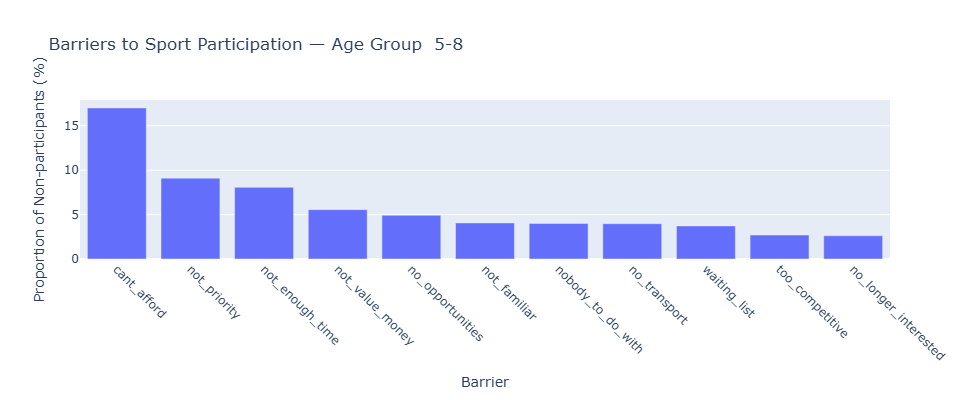

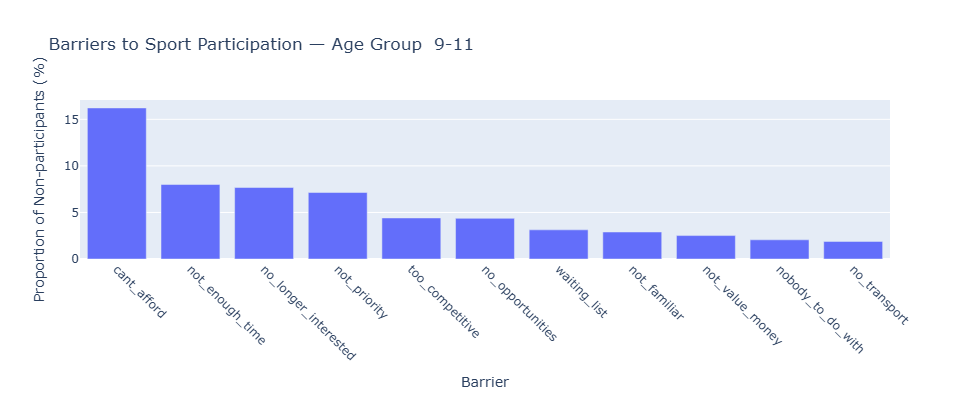

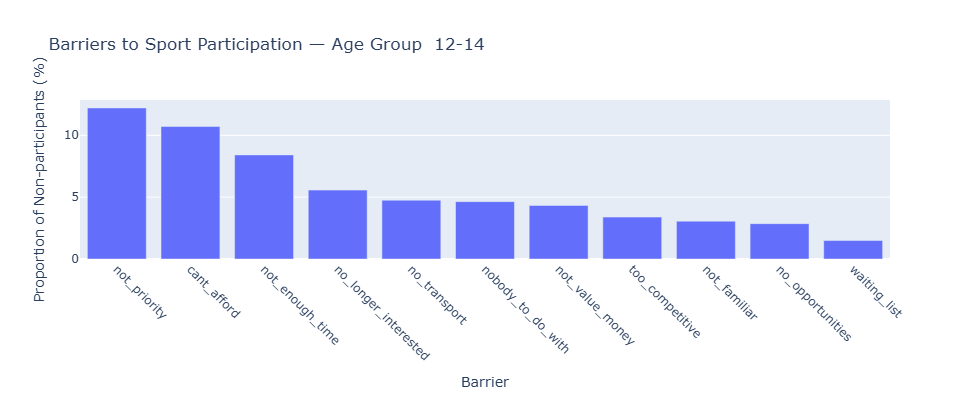

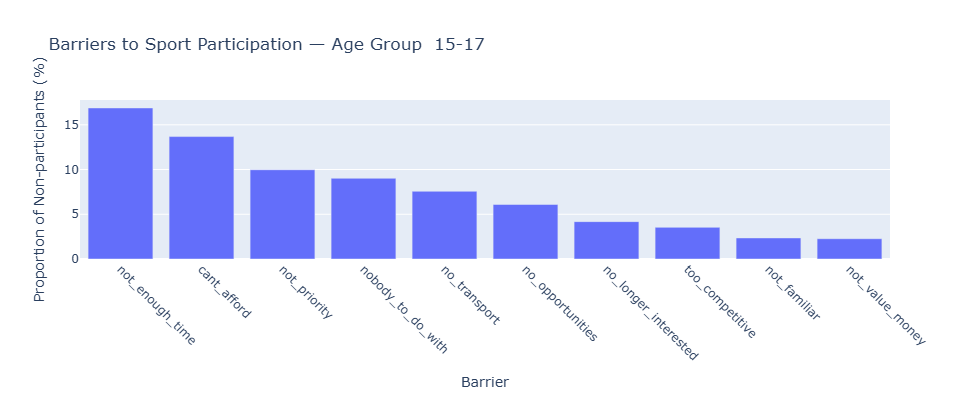

In [19]:
# Separate each age group into individual dataframes
age_groups = [' 5-8', ' 9-11', ' 12-14', ' 15-17']
dfs = {}

for age in age_groups:
    row = combined_barriers.loc[age].dropna().sort_values(ascending=False)
    dfs[age] = row
# Plot each age group separately
for age, data in dfs.items():
    fig = px.bar(
        x=data.index,
        y=data.values * 100,
        title=f'Barriers to Sport Participation — Age Group {age}',
        labels={'x': 'Barrier', 'y': 'Proportion of Non-participants (%)'},
        width=900,
        height=400
    )
    fig.update_xaxes(tickangle=45)
    fig.show()

5-8: The top barrier is cant_afford (17%), followed by not_priority (9.1%) and not_enough_time (8.1%)
9-11: The top barrier is cant_afford (16.2%), followed by no_longer_interested (7.7%) and not_priority (7.1%)
12-14: The top barrier is not_priority (12.2%), followed by cant_afford (10.7%) and not_enough_time (8.4%)
15-17: The top barrier is not_enough_time (16.9%), followed by cant_afford (13.7%) and not_priority (9.9%)

# Insights

The analysis reveals several consistent patterns across age groups (using [claude.ai](https://claude.ai/)):

| Barrier | Pattern |
|---|---|
| `cant_afford` | Consistently high across all age groups — decreases slightly with age |
| `not_enough_time` | Strongly increasing — becomes top barrier at 15-17 |
| `not_priority` | Fluctuating — peaks at 12-14 then drops slightly |
| `nobody_to_do_with` | Increasing with age — most significant at 15-17 |
| `not_value_money` | Decreasing with age — most significant for younger children |
| `no_opportunities` | Relatively stable — slight decrease with age |
| `no_transport` | Increasing with age — peaks at 15-17 |
| `too_competitive` | Relatively stable — peaks slightly at 9-11 |
| `not_familiar` | Decreasing with age — most significant for younger children |
| `waiting_list` | Decreasing with age — only present in children's table |
| `no_longer_interested` | Peaks at 9-11 then decreases — critical drop-off age |

For these barriers the ASC should come up with various strategies to address them:
1. The ASC should launch a health and lifestyle awareness campaign promoting the importance of exercise for youth, as starting early builds the foundation for a healthier life. This strategy covers barriers such as **not_priority, no_longer_interested, not_value_money and not_familiar**.
2. The ASC should implement financial support programs for youth to exercise, especially because **cant_afford** is the biggest overall barrier in the dataset. By doing this, not only can children enjoy sports but it also helps **reduce waiting times** as sport facilities receive more funds.
3. Another barrier youth face is accessibility to facilities — whether **lacking transport or enough opportunities to exercise**. By improving accessibility through better public transport infrastructure, community shuttles and building more facilities, youth will have better access to sports and better community opportunities to exercise together, addressing the **nobody_to_do_with barrier**.
4. Finally, **flexible scheduling** is important especially for older age groups (15-17) as it makes sport fit better into busy teenage lives for those who want to exercise in their spare time.

#### Data Limitation
- The analysis used only national data whereas state data could offer more specific insights where barriers might change from state to state.
- The barriers were not examined for each individual sport and were generally applied to all non-participants.
- By removing barriers that ASC cannot influence, there is a chance that certain disadvantaged groups might be underrepresented in this analysis.
- The options for barriers were predefined and participants could only choose from those options, which can lead to not capturing all the real reasons children don't participate in sport.
   
#### How analysis could be improved
- Examining each confirmed Olympic sport's barriers for non-participants then combining it with Cycle 1 findings to identify each cluster's major barriers
- Using state level data for analysis to provide more targeted strategies for each state
- Interviewing children instead of giving them fixed barrier options so the analysis has richer and more authentic data

# Question

**Concern:** From Assignment 1, the analysis looked at articles related to the social media ban and found out what the main topics in those articles were — political and legislative process, implementation and enforcement, people and community, and wellbeing and harm. However, the reason behind the social media ban was not analysed and it was more focused on after the law was introduced by the prime minister.
For ASC, the analysis found that it can use the social media ban and the access-free time it creates to attract children to sports. However, by not understanding the concerns that led to this ban, the ASC cannot have an effective marketing campaign as it would not be aligned with people's concerns.
In this analysis the focus is on the underlying concerns before the ban, especially after COVID, because during that time people were more drawn to social media, especially youth

> **Question:** What are the key themes in Guardian Australia's coverage of social media and children's mental health between 2020 and 2024 (after COVID, before the law being introduced) and does it give insights about concerns regarding this matter so the ASC can use it as a marketing strategy to attract children to sports ahead of Brisbane 2032?


### Key Stakeholders

- **ASC** — it can use these insights to have a better marketing campaign accomplishing its goal which is creating a fan base for Brisbane 2032
- **Government** — as we know from Assignment 1 the social media ban was highly debated politically. This analysis not only finds the reasons behind the ban but also gives an actual alternative way for children to use their free time through sports, so it both justifies the government's action and comes with a solution
- **Parents and Children/Youth** — are both the audience of the ASC marketing campaign
- **Sports clubs** — the marketing campaign attracts more customers and participants for these clubs

### Why this Question is significant

The social media ban significantly affects youth and it is important to know the concerns that led to this ban. For youth, they are the main actors in our analysis as well, so by understanding these concerns we can tailor our strategy and more impactfully try to attract youth to sports as it is a healthier alternative for them to spend their time. With Brisbane 2032 approaching, the ASC has a unique opportunity to make sports as the solution to the concerns raised in media coverage about children's mental health and social media use, creating a compelling and empathetic marketing campaign that attracts bith children and their parents

# Data

For getting the articles I used the search string:
'"social media" AND "children" AND "mental health" AND Australia'
as we are looking for articles about social media effects on children within Australia.
from_date = "2020-01-01" and to_date = "2024-09-01"
The date range starts from the beginning of 2020 as COVID started around that time and ends by the month the prime minister announced the social media ban. The reason for this specific date range was that the analysis wants to focus on articles that talk about concerns regarding social media for children. During COVID, children were more exposed to social media making it a perfect start date for this search.
The production office was set to Australia as we are looking for articles published within Australia.

```python
base_url = 'https://content.guardianapis.com/'
search_string = '"social media" AND "children" AND "mental health" AND Australia'
production_office = "aus"
from_date = "2020-01-01"
to_date = "2024-09-01"

full_url = base_url+f"search?q={search_string}&production-office={production_office}&from-date={from_date}&to-date={to_date}&show-fields=body&api-key={key}"
print(full_url[:120])
```

603 articles were found with this search strategy and saved into *social_media_mental_health_articles.json* so instead of fetching data every time, the analysis directly loads data from the file.

In [20]:
import json

# Load the saved JSON file
file_path = "data/"
file_name = "social_media_mental_health_articles.json"

with open(f"{file_path}{file_name}", 'r', encoding='utf-8') as fp:
    articles = json.load(fp)

print(f"Loaded {len(articles)} articles from {file_name}")

Loaded 603 articles from social_media_mental_health_articles.json


For filtering, first articles that contain 'as it happened', 'morning mail' and 'afternoon update' were removed as they contain multiple unrelated topics.


After first filtering there were 93 articles to work on, however as they were heavily related to COVID, further analysis couldn't find topics related to the analysis focus, so further filtering was required, creating relevant_keywords with the assistance of [Claude.ai](https://claude.ai/):

```python
pythonrelevant_keywords = ['social media', 'mental health', 'mental ill', 
                     'instagram', 'tiktok', 'screen time', 
                     'youth suicide', 'children online', 'teen',
                     'mental distress', 'internet']

```                     
After applying this filter, 20 relevant articles remained for the analysis.

In [21]:
relevant_keywords = ['social media', 'mental health', 'mental ill', 
                     'instagram', 'tiktok', 'screen time', 
                     'youth suicide', 'children online', 'teen',
                     'mental distress', 'internet']

filtered_articles_lda = {
    title: text for title, text in articles.items()
    if any(kw in title.lower() for kw in relevant_keywords)
    and 'as it happened' not in title.lower()
    and 'morning mail' not in title.lower()
    and 'afternoon update' not in title.lower()
}

print(len(filtered_articles_lda))

20


In [22]:
# Display all article titles for transparency
print(f"Total filtered articles: {len(filtered_articles_lda)}\n")
print("Article titles included in analysis:")
for i, title in enumerate(filtered_articles_lda.keys(), 1):
    print(f"{i}. {title[:200]}")

Total filtered articles: 20

Article titles included in analysis:
1. Social media age restrictions may push children online in secret, Australian eSafety commissioner says [2024-06-23T07:18:11Z]
2. Anthony Albanese backs campaign to ban children under 16 from social media [2024-05-21T02:44:21Z]
3. Albanese follows Dutton’s lead with tougher position on children’s social media ban [2024-06-13T07:14:13Z]
4. ‘Blunt-force approach’: LGBTQ+ advocates say proposed teen social media ban overlooks benefits [2024-07-06T20:00:47Z]
5. Pornography and social media driving rise in labia surgery, Australian report finds  [2024-06-16T15:00:51Z]
6. ‘Alarming’ surge in mental ill health among young people in face of ‘unprecedented’ challenges, experts warn [2024-08-13T22:30:25Z]
7. With youth suicide rates rising in Queensland, parents who have lost children are speaking out [2024-06-02T00:00:15Z]
8. ‘Out of control’: 60% of Australian parents and carers surveyed say social media is their biggest conce

# Analysis 

For topic modelling, [Latent Dirichlet Allocation (LDA)]( https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html) was used to identify topics for each article. The reasons for using this model were:
1. It uses CountVectorizer as input which makes it consistent with the Assignment 1 unstructured analysis.
2. LDA is more appropriate for longer documents like articles where topics overlap, especially these articles that are highly relevant to COVID and other subjects.

Making it a better option compared to NMF for this analysis.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import random

The CountVectorizer parameters were set as follows:
- max_df=0.80 — starting from a range of 0.7 to 0.9, 0.80 was chosen as it allows a word to appear in a maximum of 16 out of 20 articles, avoiding universal words that appear across all articles
- min_df=2 — a word must appear in at least 2 articles to be considered in the analysis
- max_features=10,000 — keeps the top 10,000 words for LDA to do the modelling reason for choosing this high number was to not exclude relevant words
- stop_words="english" — removes common English words that carry no meaningful information"

In [24]:
count_vectorizer = CountVectorizer(max_df=0.80, min_df=2, max_features=10000, stop_words="english")
count_dt_matrix = count_vectorizer.fit_transform(filtered_articles_lda.values())

feature_names = count_vectorizer.get_feature_names_out()

To find the optimal number of topics, k values from 3 to 10 were tested using a loop:

- k=3 — too few topics, merges important distinct themes together. Suicide and mental health concerns are combined with general parental concerns losing important distinctions
- k=4 — better but still merges parental concerns and age restriction debate into one broad topic
- k=5 — introduces the youth community topic but suicide still not clearly separated
- k=6 — suicide starts appearing but parental concerns and pandemic mental health still overlap
- k=7 — optimal choice. Produces 7 distinct topics including clearly separated suicide prevention, self-diagnosis disorders, Meta/platforms, and parental concerns. Topics 2 and 4 have very low weights indicating noise but the meaningful topics are well separated
- k=8 — starts splitting meaningful topics unnecessarily. Self-diagnosis and TikTok disorders split across two topics
- k=9 — adds political campaign topic but introduces more noise
- k=10 — over-splits topics with meaningless additions like 'banks', 'quit', 'love' — clearly noise

k=7 was chosen as it provides the most meaningful and distinct topics without over-splitting."Sonnet 4.6

In [25]:
for num_topics in [3, 4, 5, 6, 7, 8, 9, 10]:
    print(f"\n{'='*50}")
    print(f"num_topics = {num_topics}")
    print('='*50)
    
    lda_model = LatentDirichletAllocation(
        n_components=num_topics, 
        max_iter=20, 
        learning_method='online',
        random_state=42
    )
    doc_topic_matrix = lda_model.fit_transform(count_dt_matrix)
    topic_term_matrix = lda_model.components_
    
    for index, topic in enumerate(topic_term_matrix):
        zipped = zip(feature_names, topic)
        top_terms = dict(sorted(zipped, key=lambda t: t[1], reverse=True)[:8])
        top_terms_list = {key: round(top_terms[key], 2) for key in top_terms.keys()}
        print(f"topic_{index}: {list(top_terms_list.keys())}")


num_topics = 3
topic_0: ['says', 'like', 'age', 'time', 'just', 'parents', 'year', 'pandemic']
topic_1: ['meta', 'news', 'publishers', 'content', 'year', 'police', 'told', 'government']
topic_2: ['says', 'parents', 'pandemic', 'help', 'daughter', 'like', 'carers', 'difficult']

num_topics = 4
topic_0: ['says', 'like', 'age', 'time', 'just', 'parents', 'year', 'suicide']
topic_1: ['meta', 'news', 'publishers', 'content', 'year', 'police', 'told', 'government']
topic_2: ['says', 'daughter', 'parents', 'help', 'pandemic', 'carers', 'difficult', 'like']
topic_3: ['self', 'paper', 'disorders', 'says', 'videos', 'tiktok', 'number', 'like']

num_topics = 5
topic_0: ['says', 'like', 'age', 'time', 'just', 'parents', 'year', 'suicide']
topic_1: ['meta', 'news', 'publishers', 'content', 'year', 'police', 'told', 'code']
topic_2: ['says', 'help', 'pandemic', 'parents', 'like', 'daughter', 'difficult', 'aged']
topic_3: ['self', 'paper', 'disorders', 'says', 'videos', 'tiktok', 'number', 'like']
t

The code for LDA was adapted from the IFN619 course materials (C1-SemistructuredAnalytics_B). random_state=42 was set to ensure reproducibility — as LDA is a stochastic algorithm, setting a fixed random state ensures the same topics are produced every run. The value 42 is a common convention in data science, referencing "The Hitchhiker's Guide to the Galaxy" 
The topics found in the first iteration were saved to data/lda_topics.json so the conclusions remain consistent across the analysis without needing to rerun LDA every time.

In [26]:
# Set up and run LDA (exactly as in course)

num_topics = 7
lda_model = LatentDirichletAllocation(
    n_components=num_topics,
    max_iter=20,
    learning_method='online',
    random_state=42
)
doc_topic_matrix = lda_model.fit_transform(count_dt_matrix)

```python
doc_topic_matrix = lda_model.fit_transform(count_dt_matrix)
topic_term_matrix = lda_model.components_

# Get the topics and their terms 
lda_topic_dict = {}
for index, topic in enumerate(topic_term_matrix):
    zipped = zip(feature_names, topic)
    top_terms = dict(sorted(zipped, key=lambda t: t[1], reverse=True)[:10])
    top_terms_list = {key: round(top_terms[key], 4) for key in top_terms.keys()}
    lda_topic_dict[f"topic_{index}"] = top_terms_list

for k, v in lda_topic_dict.items():
    print(k)
    print(v)
    print()

```

Save LDA topic dictionary to file
```python
with open('data/lda_topics.json', 'w', encoding='utf-8') as fp:
    json.dump(lda_topic_dict, fp)

print("LDA topics saved!")
```

In [27]:
with open('data/lda_topics.json', 'r', encoding='utf-8') as fp:
    lda_topic_dict = json.load(fp)

print("LDA topics loaded!")
lda_topic_dict

LDA topics loaded!


{'topic_0': {'age': 37.3126,
  'says': 33.559,
  'parents': 26.9314,
  'just': 23.3103,
  'pandemic': 22.4495,
  'time': 21.5576,
  'like': 20.681,
  'use': 20.6096,
  'really': 20.5398,
  'year': 20.5223},
 'topic_1': {'meta': 23.4395,
  'news': 20.6157,
  'publishers': 11.1114,
  'content': 6.7222,
  'government': 4.9577,
  'code': 4.3053,
  'revenue': 4.1749,
  'facebook': 4.1288,
  'told': 3.9292,
  'issues': 3.9278},
 'topic_2': {'says': 0.3215,
  'age': 0.2736,
  'pandemic': 0.2654,
  'like': 0.2645,
  'self': 0.2634,
  'help': 0.2586,
  'difficult': 0.247,
  'parents': 0.2466,
  'just': 0.2461,
  'work': 0.2454},
 'topic_3': {'self': 9.4061,
  'paper': 7.6348,
  'disorders': 5.7458,
  'says': 4.7894,
  'videos': 3.8945,
  'tiktok': 3.8925,
  'number': 3.8869,
  'like': 3.8591,
  'pandemic': 3.8374,
  'increasing': 2.9819},
 'topic_4': {'community': 0.2713,
  'pandemic': 0.2571,
  'youth': 0.2449,
  'really': 0.2435,
  'aged': 0.2368,
  'like': 0.2368,
  'crisis': 0.2361,
  'comm

Topic 0 — age, parents, pandemic, time, use
→ Broad parental concern about children's social media use during and after COVID. Parents worried about how much time children spend online and the age at which they access these platforms.

Topic 1 — meta, news, publishers, content, government, code, revenue, facebook
→ Platform accountability and regulation. About Meta and Facebook's relationship with news publishers and government regulation — less directly about mental health.

Topic 2 — age, pandemic, self, help, difficult, parents
→ Very low weights — noise topic. Likely a mix of leftover words from other topics.

Topic 3 — self, paper, disorders, tiktok, videos, number, increasing
→ Self-diagnosis disorders on TikTok. Young people watching videos about mental health conditions and self-diagnosing — directly linked to the research paper about Tourette syndrome.

Topic 4 — community, pandemic, youth, crisis, commission
→ Very low weights — noise topic. General youth community and mental health crisis language.

Topic 5 — mirror, platforms, old, time, content
→ Personal experience with social media platforms and self-image. About how social media acts as a mirror affecting self-perception.

Topic 6 — suicide, death, care, need, prevention, daughter, queensland
→ Youth suicide crisis. The most serious mental health topic — directly about rising suicide rates among Queensland youth.


It is worth to mention that Topics 2 and 4 have very low weights across all their keywords compared to other topics, suggesting they are noise topics rather than meaningful distinct themes. These will not be included in the insights section.[Claude.ai](https://claude.ai/)

In [28]:
# Create a dataframe to hold top terms for each analysis type
titles = list(filtered_articles_lda.keys())
terms_df = pd.DataFrame(index=range(len(titles)), columns=['title', 'lda'])
terms_df['title'] = titles
terms_df

,title,lda
0,Social media age restrictions may push childre...,NaN
1,Anthony Albanese backs campaign to ban childre...,NaN
2,Albanese follows Dutton’s lead with tougher po...,NaN
3,‘Blunt-force approach’: LGBTQ+ advocates say p...,NaN
4,Pornography and social media driving rise in l...,NaN
5,‘Alarming’ surge in mental ill health among yo...,NaN
6,"With youth suicide rates rising in Queensland,...",NaN
7,‘Out of control’: 60% of Australian parents an...,NaN
8,Social media is making kids sad – and it’s bad...,NaN
9,Sydney university stabbing: teenage boy who al...,NaN


In [29]:
for idx in terms_df.index:
    lda_topics = dict(sorted(
        zip(feature_names, doc_topic_matrix[idx]), 
        key=lambda t: t[1], reverse=True
    )[:10])
    terms_df.at[idx, 'lda'] = list(lda_topics.keys())

In [30]:
terms_df['dominant_topic'] = [
    f"topic_{doc_topic_matrix[i].argmax()}" 
    for i in range(len(titles))
]
lda_topic_dict
topic_words = {f'topic_{i}': list(lda_topic_dict[f'topic_{i}'].keys()) 
               for i in range(num_topics)}

terms_df['topic_words'] = terms_df['dominant_topic'].map(topic_words)
terms_df[['title', 'dominant_topic', 'topic_words']].sort_values('dominant_topic')


,title,dominant_topic,topic_words
0,Social media age restrictions may push childre...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
16,‘It breaks my heart’: Australian parents say m...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
15,Social media giants face $10m fines for privac...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
14,Younger girls increasingly presenting to Austr...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
12,Youth mental health: Australia needs to look b...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
18,Teens and vaping: ‘We would have had a nicotin...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
8,Social media is making kids sad – and it’s bad...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
19,Friday briefing: rollout of Covid jabs for tee...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
5,‘Alarming’ surge in mental ill health among yo...,topic_0,"[age, says, parents, just, pandemic, time, lik..."
4,Pornography and social media driving rise in l...,topic_0,"[age, says, parents, just, pandemic, time, lik..."


For visualisation, a table was chosen with columns containing article titles, topic names and topic words. Topics and their associated keywords are better displayed within a table format as they are not easily readable through graphs.

In [31]:
# Display content of Topic 0
topic_3_6_titles = terms_df[
    terms_df['dominant_topic'].isin(['topic_0'])
]['title'].tolist()

for title in topic_3_6_titles:
    # Find matching article in filtered_articles_lda
    for article_title, text in filtered_articles_lda.items():
        if title[:50] in article_title:
            print(f"\n{'='*60}")
            print(f"TITLE: {article_title}")
            print(f"TOPIC: {terms_df[terms_df['title'].str.contains(title[:30],  regex=False)]['dominant_topic'].values[0]}")
            print(f"{'='*60}")
            print(text[:2000])
            print("...")
            break


TITLE: Social media age restrictions may push children online in secret, Australian eSafety commissioner says [2024-06-23T07:18:11Z]
TOPIC: topic_0
Restricting children from social media could risk limiting their access to critical social support and could result in them accessing social media in secret, Australia’s online safety regulator has warned. 
The opposition leader, Peter Dutton, this month said the Coalition would ban under 16s from social media within 100 days should they win the next election. The Albanese government is undertaking a $6.5m trial of age assurance technology and is assessing at what age children should be able to access social media as part of a wide-ranging parliamentary inquiry on social media and Australian society. 
In its submission to the inquiry, the eSafety commissioner’s office said that while 45% of young people aged 14 to 17 reported being treated in a hurtful or nasty way online, and social media can have acute risks to children such as online gr

Topic 0 represents the broad public and parental concern about children's social media use and its impact on mental health. The keywords suggest a narrative centred around age restrictions, parental anxiety and the role of the pandemic in accelerating social media use among children.

In [32]:
# Display content of Topic 3 and Topic 6 articles
topic_3_6_titles = terms_df[
    terms_df['dominant_topic'].isin(['topic_3', 'topic_6'])
]['title'].tolist()

for title in topic_3_6_titles:
    # Find matching article in filtered_articles_lda
    for article_title, text in filtered_articles_lda.items():
        if title[:50] in article_title:
            print(f"\n{'='*60}")
            print(f"TITLE: {article_title}")
            print(f"TOPIC: {terms_df[terms_df['title'].str.contains(title[:30],  regex=False)]['dominant_topic'].values[0]}")
            print(f"{'='*60}")
            print(text[:2000])
            print("...")
            break


TITLE: With youth suicide rates rising in Queensland, parents who have lost children are speaking out [2024-06-02T00:00:15Z]
TOPIC: topic_6
A black-and-white picture book chronicles the mental health struggles of 16-year-old Skyla Lomas. Written months before her death, it describes “the bad guy” who “lived inside” her and the “constant battle” in her mind. “Nowhere to run, nowhere to hide. All alone and get very numb,” Lomas wrote. Then, out of the dark, the book suddenly transitions into full colour. Beside a ship sailing into a bay are the words: “Never give up. Things can change.”   Related: Senior suicide: the silent generation speaking up on a quiet killer    It’s been seven years since Lomas took her own life and since then the rate of child suicide has steadily increased in Queensland. In the past five years, 128 children have died by suicide, with the rate increasing by 1.9% each year over that period, according to an annual report by the Queensland Family and Child Commissio

### ‘Urgent need’ to understand link between teens self-diagnosing disorders and social media use, experts say 


This article talks about the self-diagnosing disorder phenomenon and how it's linked to social media, especially TikTok. The article starts with Tourette syndrome and how diagnoses picked up after influencers on TikTok started creating content of themselves having tics. The article also mentions that self-diagnosed Tourette syndrome tics are quite different from classical syndromes before this widespread familiarisation with this syndrome.
Moreover, the article talks about how these self-diagnoses don't just mean they are not suffering, especially after the huge uptick in depression and anxiety worldwide following the pandemic, particularly among children. These self-diagnoses are a way to explain their symptoms as there are barriers to reaching medical care. Other possibilities raised by the authors is that those affected are trying to seek affirmation and attention, acquire social capital in online communities, or maintain an unconventional identity that masks feelings of anxiety, depression, and possibly lower self-esteem.
The article also talks about other self-diagnosed diseases such as dissociative identity disorder and borderline personality disorder and videos demonstrating these disorders. However, related medical research shows that only a few of these self-diagnosed conditions were true and most were not appropriately diagnosed with the correct condition

### With youth suicide rates rising in Queensland, parents who have lost children are speaking out

This article mostly talks about the increasing rate of suicide (1.9% per year) in Queensland and mentions that the drivers of youth suicide are complex with no single cause. The article highlights both cyberbullying and sextortion as contributing factors, especially because children are more vulnerable than adults when it comes to shame and humiliation, which may trigger suicidal behaviour.

The article says that suicide prevention needs to be focused across multiple settings including the political service system, schools and online social media environments.

# Insights

#### Key findings
The analysis identified 5 meaningful themes from the articles:

- Topic 0 mainly talks about parents' concerns about children's social media usage and discussion on the age children can access social media
- Topic 1 mainly talks about platform accountability and regulation and how social media companies use their platform to feed certain data to people
- Topic 3 mainly talks about the self-diagnosis issues in children who watch videos regarding mental health
- Topic 5 talks about how social media can affect self-perception
- Topic 6 mainly talks about how suicide rates keep increasing among children and talks about factors that relate to it

By focusing on Topics 0, 3 and 6 the following conclusion has been made:
Topic 0 shows that before the social media ban there was a community concern, especially among parents, about children's social media usage — particularly because of the effects it has on children such as cyberbullying and sextortion that leads children to commit suicide (Topic 6) and self-diagnosis of mental disorders among children who watch related mental health videos on these platforms (Topic 3).
All these findings can help the ASC come up with a marketing campaign to attract children to sports and eventually create the fan base it wants for Brisbane 2032
#### Strategic recommendations for ASC
Based on the findings, the ASC now knows that parental concern was a great factor that led to the social media ban. We know from Assignment 1 that the ban was heavily debated politically, which shows that if the ASC can create a marketing campaign, both parents and the government can be its supporters.
Therefore the marketing campaign should not only target children — it should target adults (parents) as well. The marketing campaign should demonstrate the following:

- Sports can be a great alternative to social media as they are fun and engaging for children, and with the social media ban creating free time for children, ASC has a window of opportunity to act now before children find other alternatives
- Sports will provide children a sense of community and purpose which are two of the most important factors that protect children from mental health issues. Topic 3 shows children are seeking identity and community on line through mental health content — sport provides this in a much healthier way
- Topic 6 shows youth suicide is increasing linked to cyberbullying and online shame. Sport can directly address this as physical activity, team belonging and achievement are proven protective factors against depression and suicidal thoughts — giving ASC a powerful message that sport is not just fun, it is a mental health intervention
- Sport communities tend to be a much healthier environment for children if governed properly, saving children from dangerous behaviours

Also, for the 15-17 age group who can legally access social media, ASC should use these platforms strategically to promote sport as a community and identity alternative, creating a bridge between the digital world and the sporting community ASC wants to build ahead of Brisbane 2032
#### Data Limitation
- We are only using one source for our data which is Guardian API, this has led to a small sample size which affects the findings. Moreover, it has biases as we are using one news outlet which has a specific political point of view.
- LDA works better with larger datasets and this can affect our analysis
- Some noise words weren't captured by the stopwords filter
- The date range (2020-2024) may not capture all relevant concerns — some mental health impacts of social media were documented before COVID
#### How analysis could be improved
- using multiple news outlets instead of just Guardian API would give a more balanced and less biased view of the concerns
- expanding the date range further back before 2020 could capture mental health concerns about social media that existed before COVID
- adding more custom stopwords to remove noise words like 'says', 'just', 'like' that dominated some topics would give cleaner and more meaningful topics
- using both LDA and NMF and comparing their results could give a more complete picture of the themes

# conclusion 

Across all three cycles, the analysis provides ASC with a comprehensive strategy:

- Cycle 1 → which sports to invest in and how to target age groups
- Cycle 2 → what barriers to remove to grow participation
- Cycle 3 → how to market sport using mental health narrative